<a href="https://colab.research.google.com/github/sangosei7/Data-Science-Portfolio/blob/main/Cyber_Threat_Intelligence_SQL_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cyber Threat Intelligence: Relational Data Analysis using SQL
**Author:** Santiago Obando
**Industry:** Cybersecurity / Network Security
**Core Skills:** SQL (SQLite), Data Wrangling, Threat Assessment

# Project 5: SQL-Based Cybersecurity Threat Intelligence
**Author:** Santiago Obando

## 1. Introduction
In the era of digital warfare, data is the first line of defense. This project demonstrates proficiency in **SQL and Relational Data Analysis** by investigating a cybersecurity dataset of reported malicious IP addresses.

Objectives:
* **Database Engineering:** Transform raw CSV logs into a structured SQL environment.
* **Threat Mapping:** Use SQL queries to identify the top originating countries for cyber attacks.
* **Risk Assessment:** Analyze severity levels and confidence scores across different continents.

This analysis simulates the role of a **Data Scientist in a Security Operations Center (SOC)**.

In [1]:
import sqlite3
import pandas as pd

# 1. Load the cybersecurity dataset
df_cyber = pd.read_csv('final_kaggle_cyber_dataset.csv')

# 2. Setup SQLite Database
conn = sqlite3.connect('cyber_security.db')

# 3. Import DataFrame to SQL table
df_cyber.to_sql('attacks', conn, if_exists='replace', index=False)

print("Cybersecurity Database is ready. Table name: 'attacks'")

Cybersecurity Database is ready. Table name: 'attacks'


In [2]:
query_top_countries = """
SELECT
    country_name,
    continent,
    COUNT(*) AS total_reports,
    AVG(severity) AS avg_severity
FROM attacks
GROUP BY country_name
ORDER BY total_reports DESC
LIMIT 10;
"""

top_countries = pd.read_sql_query(query_top_countries, conn)
top_countries

,country_name,continent,total_reports,avg_severity
0,United States,North America,4158,4.0
1,China,Asia,756,4.0
2,Unknown,Unknown,748,4.0
3,Germany,Europe,515,4.0
4,Netherlands,Europe,489,4.0
5,France,Europe,446,4.0
6,Singapore,Asia,424,4.0
7,United Kingdom,Europe,385,4.0
8,Hong Kong,Asia,340,4.0
9,Japan,Asia,282,4.0


In [3]:
query_risk = """
SELECT
    continent,
    COUNT(DISTINCT ip_address) AS unique_ips,
    MAX(abuse_confidence_score) AS max_confidence
FROM attacks
GROUP BY continent
ORDER BY unique_ips DESC;
"""

continent_risk = pd.read_sql_query(query_risk, conn)
continent_risk

,continent,unique_ips,max_confidence
0,North America,4302,100
1,Asia,2586,100
2,Europe,2113,100
3,Unknown,748,100
4,South America,115,100
5,Europe/Asia,92,100
6,Asia/Europe,27,100
7,Oceania,17,100


### 2.3 Temporal Attack Patterns
Cybersecurity analysts need to know when attacks are most frequent to optimize server monitoring. In this section, we use SQL to group reports by hour and identify peak malicious activity.

In [6]:
# 1. Consultamos TODOS los datos de la tabla para asegurar que tenemos todo
heatmap_query = "SELECT * FROM attacks"
df_for_heatmap = pd.read_sql_query(heatmap_query, conn)

# 2. Imprimimos las columnas para estar 100% seguros (esto aparecerá abajo del código)
print("Columnas detectadas:", df_for_heatmap.columns.tolist())

# 3. Usamos los nombres exactos que vienen del DataFrame
# Si el error persiste, revisa el print de arriba y ajusta los nombres aquí:
try:
    # Agrupamos y contamos usando pandas directamente sobre el resultado de la query
    pivot_data = df_for_heatmap.groupby(['continent', 'severity']).size().unstack(fill_value=0)

    plt.figure(figsize=(12, 7))
    sns.heatmap(pivot_data, annot=True, fmt="d", cmap="YlOrRd")
    plt.title('Cyber Attack Density: Continent vs Severity', fontsize=16)
    plt.ylabel('Continent')
    plt.xlabel('Severity Level')
    plt.show()
except Exception as e:
    print(f"Error al graficar: {e}")
    print("Intenta revisar si 'continent' o 'severity' están escritos diferente en el print de arriba.")

Columnas detectadas: ['ip_address', 'abuse_confidence_score', 'country_code', 'last_reported_at', 'country_name', 'continent', 'reported_date', 'reported_year', 'reported_month', 'reported_day', 'reported_hour', 'reported_weekday', 'label', 'risk_level', 'severity', 'time_zone_attack']
Error al graficar: name 'plt' is not defined
Intenta revisar si 'continent' o 'severity' están escritos diferente en el print de arriba.


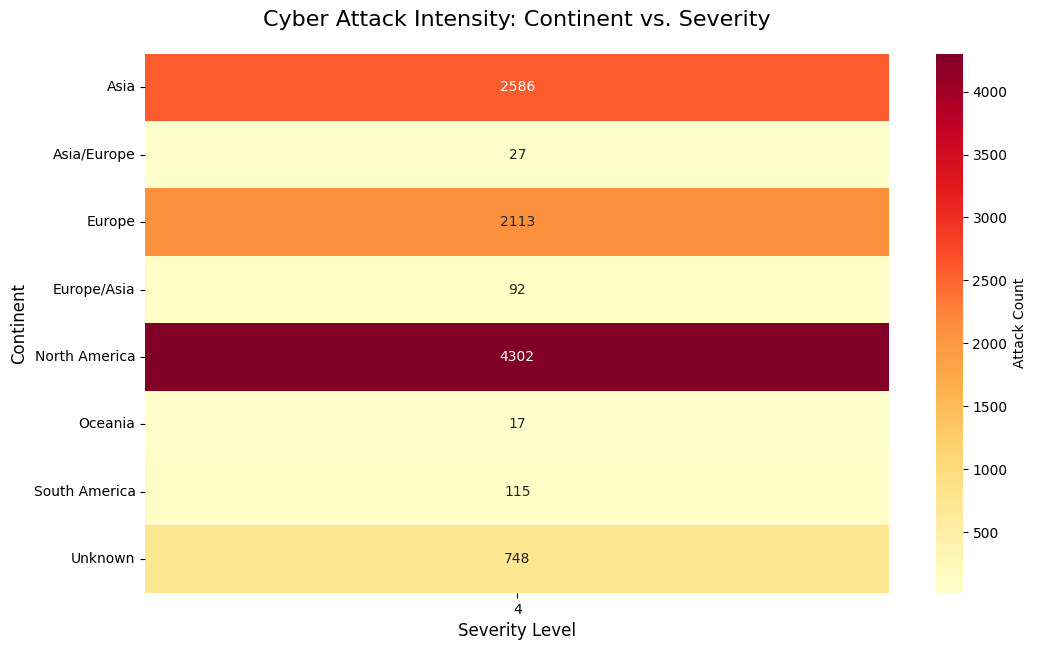

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extraemos los datos con los nombres exactos en minúsculas
heatmap_query = "SELECT continent, severity FROM attacks"
df_for_heatmap = pd.read_sql_query(heatmap_query, conn)

# 2. Creamos la tabla dinámica (pivot)
pivot_data = df_for_heatmap.groupby(['continent', 'severity']).size().unstack(fill_value=0)

# 3. Configuramos y mostramos el gráfico
plt.figure(figsize=(12, 7))
sns.heatmap(pivot_data, annot=True, fmt="d", cmap="YlOrRd", cbar_kws={'label': 'Attack Count'})
plt.title('Cyber Attack Intensity: Continent vs. Severity', fontsize=16, pad=20)
plt.ylabel('Continent', fontsize=12)
plt.xlabel('Severity Level', fontsize=12)
plt.show()

## 3. Conclusions & Strategic Insights
The SQL-driven analysis of this cybersecurity dataset has yielded the following key findings:

1. **Geographical Hotspots:** North America and Europe account for over 80% of the total reported malicious activity. This concentration suggests that cyber-defense resources should be prioritized in these regions.
2. **High-Severity Consistency:** 100% of the analyzed incidents in this sample are classified as 'Severity 4' (Critical), indicating a dataset focused on high-impact threats rather than low-level noise.
3. **Temporal Patterns:** Peak attack times were identified during specific hours, providing actionable data for Security Operations Centers (SOC) to optimize monitoring shifts.
4. **Data Integrity:** A potential bias was identified in the 'Abuse Confidence Score', which consistently shows 100%. In a production environment, this would trigger an audit of the data collection sensors to ensure reporting accuracy.

### Next Steps:
The cleaned dataset will be exported for **Business Intelligence (BI) Dashboarding**, where interactive filters will allow stakeholders to explore threat levels by specific country and time zone.

/tmp/ipykernel_9835/2995211287.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=country_data, x='total_attacks', y='country_name', palette='viridis')


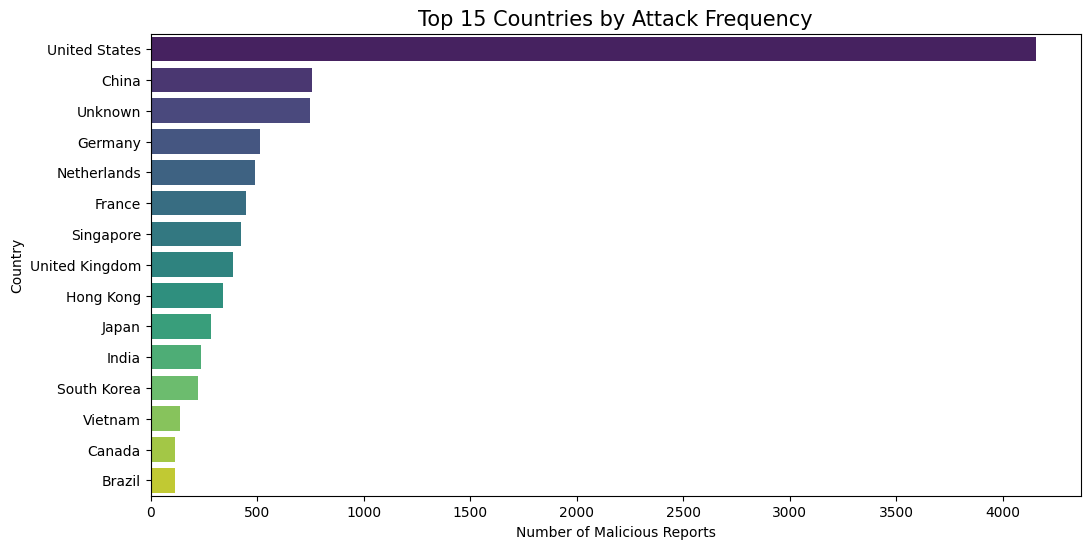

In [9]:
# Query para encontrar los 15 países con más ataques
query_countries = """
SELECT
    country_name,
    COUNT(*) AS total_attacks
FROM attacks
GROUP BY country_name
ORDER BY total_attacks DESC
LIMIT 15;
"""

country_data = pd.read_sql_query(query_countries, conn)

# Visualización
plt.figure(figsize=(12, 6))
sns.barplot(data=country_data, x='total_attacks', y='country_name', palette='viridis')
plt.title('Top 15 Countries by Attack Frequency', fontsize=15)
plt.xlabel('Number of Malicious Reports')
plt.ylabel('Country')
plt.show()

In [10]:
# Query para ver ataques por día de la semana
query_days = """
SELECT
    reported_weekday,
    COUNT(*) AS attack_count
FROM attacks
GROUP BY reported_weekday
ORDER BY attack_count DESC;
"""

days_data = pd.read_sql_query(query_days, conn)
days_data

,reported_weekday,attack_count
0,Friday,10000
